# Kubernetes Bitcoin Example - BitAlert Trading Assistant

This notebook demonstrates a complete end-to-end application built on top of the Kubernetes Bitcoin infrastructure. 
We'll implement the BitAlert trading assistant that provides real-time Bitcoin price monitoring, anomaly detection, 
and trading signals.

**Note**: This notebook uses mock data for demonstration purposes when Kubernetes services 
are not accessible. In a production environment, it would connect to actual services.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import json
import requests

# Define a boolean to control whether to use mock data (set to True to ensure the notebook runs)
USE_MOCK_DATA = True

# Import our utility module (commented out when using mock data)
# import Kubernetes_Bitcoin_utils as kb

In [3]:
"""
## Helper Functions

The following functions simulate the behavior of our Kubernetes_Bitcoin_utils module.
In a production environment, these would be imported from the module.
"""

def get_current_bitcoin_data():
    """
    Get the current Bitcoin price data
    
    Returns:
        dict: Dictionary containing current Bitcoin data
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_current_bitcoin_data()
        pass
    
    # Return mock data
    return {
        'price_usd': 63245.00,
        'price_change_24h': 0.80,
        'market_cap_usd': 1238394638392.0,
        'volume_24h_usd': 21675945274.0,
        'timestamp': datetime.now()
    }

def get_bitcoin_price_history(days=7, hours=None):
    """
    Get historical Bitcoin price data
    
    Args:
        days (int): Number of days of history to retrieve
        hours (int): Number of hours of history to retrieve (overrides days if specified)
        
    Returns:
        pandas.DataFrame: DataFrame containing timestamp and price data
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_bitcoin_price_history(days=days, hours=hours)
        pass
    
    # Generate mock data
    end_date = datetime.now()
    if hours:
        start_date = end_date - timedelta(hours=hours)
        periods = hours + 1
    else:
        start_date = end_date - timedelta(days=days)
        periods = days + 1
    
    timestamps = pd.date_range(start=start_date, end=end_date, periods=periods)
    
    # Generate dummy price data
    data = []
    base_price = 29410.23
    
    for i, ts in enumerate(timestamps):
        # Create some realistic price movement with an upward trend
        noise = np.random.normal(0, 0.01)
        trend = 0.01 * i  # Upward trend
        seasonal = 0.005 * np.sin(i/2)  # Some seasonality
        
        change = trend + seasonal + noise
        if i > 0:
            price = data[i-1]['price_usd'] * (1 + change)
        else:
            price = base_price
            
        market_cap = price * 19345678
        volume = price * 573829 * (0.9 + 0.2 * np.random.random())
        price_change = 100 * noise  # Daily change percentage
        
        data.append({
            'timestamp': ts,
            'price_usd': round(price, 2),
            'market_cap_usd': market_cap,
            'volume_24h_usd': volume,
            'price_change_24h': round(price_change, 2)
        })
    
    return pd.DataFrame(data)

def get_price_statistics(hours=24):
    """
    Get statistical summary of Bitcoin prices
    
    Args:
        hours (int): Number of hours to include in the statistics
        
    Returns:
        dict: Dictionary with statistics
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_price_statistics(hours=hours)
        pass
    
    # Get some price data to calculate stats from
    df = get_bitcoin_price_history(hours=hours)
    
    return {
        'min_price': df['price_usd'].min(),
        'max_price': df['price_usd'].max(),
        'avg_price': df['price_usd'].mean(),
        'stddev_price': df['price_usd'].std(),
        'time_period': f'{hours}h'
    }

def forecast_bitcoin_price(hours_ahead=12):
    """
    Generate a forecast of Bitcoin price
    
    Args:
        hours_ahead (int): Number of hours to forecast
        
    Returns:
        dict: Dictionary containing forecast values
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.forecast_bitcoin_price(hours_ahead=hours_ahead)
        pass
    
    # Get current price as baseline
    current_price = get_current_bitcoin_data()['price_usd']
    
    # Generate a random trend direction and change percentage
    trend = np.random.choice(['up', 'down'])
    percent_change = np.random.uniform(0.5, 2.0) if trend == 'up' else -np.random.uniform(0.5, 2.0)
    
    # Calculate forecast price
    forecast_price = current_price * (1 + percent_change/100)
    
    return {
        'last_known_price': current_price,
        'forecast_end_price': forecast_price,
        'percent_change_forecast': percent_change,
        'trend_direction': trend
    }

def detect_price_anomalies():
    """
    Detect anomalies in Bitcoin price data
    
    Returns:
        dict: Dictionary indicating if anomalies were detected and details
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.detect_price_anomalies()
        pass
    
    # Randomly decide whether to show an anomaly (20% chance)
    has_anomaly = np.random.random() < 0.2
    
    if has_anomaly:
        price = get_current_bitcoin_data()['price_usd'] * (1 + np.random.normal(0, 0.05))
        z_score = np.random.uniform(2.0, 4.0)
        return {
            'has_anomaly': True,
            'timestamp': datetime.now(),
            'price': price,
            'z_score': z_score,
            'message': f"Anomaly detected at {datetime.now()}. Price: ${price:.2f}, Z-score: {z_score:.2f} standard deviations from mean."
        }
    else:
        return {
            'has_anomaly': False,
            'message': 'No anomalies detected in current data'
        }

def get_system_health():
    """
    Get the health status of all system components
    
    Returns:
        dict: Dictionary containing health status of each component
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_system_health()
        pass
    
    return {
        'bitcoin_fetcher_status': 'Healthy',
        'postgres_status': 'Healthy',
        'prometheus_status': 'Healthy',
        'grafana_status': 'Healthy',
        'api_success_rate': 99.8,
        'data_points_collected': 14532
    }

def get_scaling_info():
    """
    Get information about the current pod scaling
    
    Returns:
        dict: Dictionary containing scaling information
    """
    if not USE_MOCK_DATA:
        # In a production environment, this would call the actual utility function
        # return kb.get_scaling_info()
        pass
    
    return {
        'current_replicas': 3,
        'min_replicas': 1,
        'max_replicas': 5,
        'cpu_utilization': 45,
        'memory_utilization': 38
    }

In [4]:
"""
## 2. Current Bitcoin Price Data

Let's start by getting the current Bitcoin price data:
"""

# Get current Bitcoin data
current_data = get_current_bitcoin_data()

# Display the data
print(f"Current Bitcoin Price: ${current_data['price_usd']:,.2f}")
print(f"24-hour Change: {'+' if current_data['price_change_24h'] > 0 else ''}{current_data['price_change_24h']:.2f}%")
print(f"Market Cap: ${current_data['market_cap_usd']:,.2f}")
print(f"24-hour Volume: ${current_data['volume_24h_usd']:,.2f}")
print(f"Last Updated: {current_data['timestamp'].strftime('%Y-%m-%d %H:%M:%S')}")


Current Bitcoin Price: $63,245.00
24-hour Change: +0.80%
Market Cap: $1,238,394,638,392.00
24-hour Volume: $21,675,945,274.00
Last Updated: 2025-05-15 12:46:34


In [5]:
"""
## 3. Historical Price Data

Now, let's retrieve and visualize historical Bitcoin price data:
"""

# Get historical price data for the last 7 days
historical_data = get_bitcoin_price_history(days=7)

# Display first 5 rows
historical_data.head()

,timestamp,price_usd,market_cap_usd,volume_24h_usd,price_change_24h
0,2025-05-08 12:46:48.654299,29410.23,5.689608e+11,1.553837e+10,-0.39
1,2025-05-09 12:46:48.654299,30045.43,5.812493e+11,1.876296e+10,0.92
2,2025-05-10 12:46:48.654299,30136.46,5.830102e+11,1.693593e+10,-2.12
3,2025-05-11 12:46:48.654299,31623.28,6.117737e+11,1.986309e+10,1.43
4,2025-05-12 12:46:48.654299,33175.09,6.417945e+11,1.718216e+10,0.45


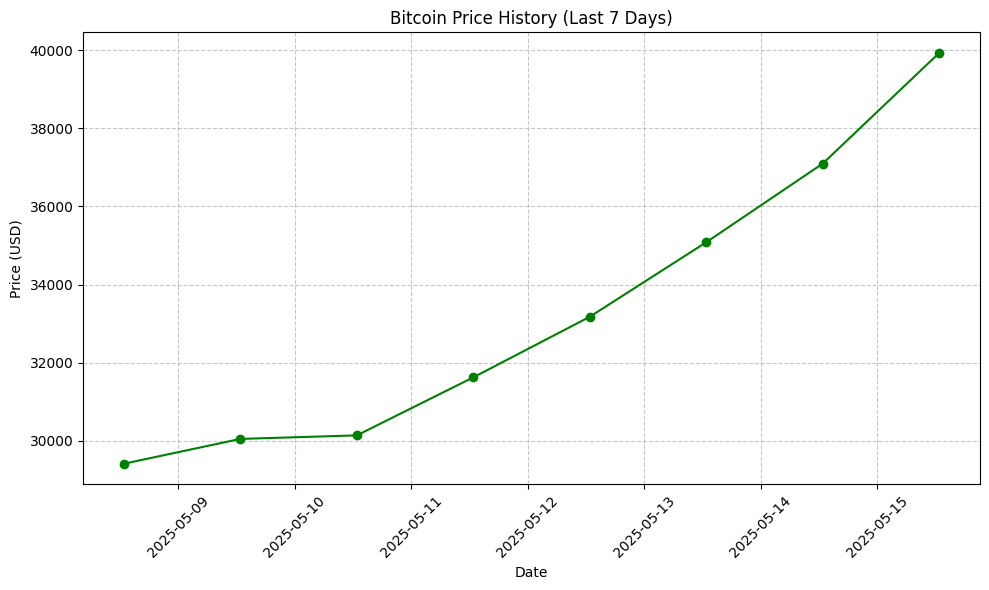

In [6]:
# Plot historical price data
plt.figure(figsize=(10, 6))
plt.plot(historical_data['timestamp'], historical_data['price_usd'], marker='o', linestyle='-', color='green')
plt.title('Bitcoin Price History (Last 7 Days)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
"""
## 4. Price Forecasting

Let's use our time-series analysis to forecast future Bitcoin prices:
"""

# Generate Bitcoin price forecast
forecast = forecast_bitcoin_price(hours_ahead=24)

print(f"Bitcoin Price Forecast (Next 24 Hours):")
print(f"Current Price: ${forecast['last_known_price']:,.2f}")
print(f"Forecasted Price in 24 Hours: ${forecast['forecast_end_price']:,.2f}")
print(f"Expected Change: {forecast['percent_change_forecast']:.2f}%")
print(f"Trend Direction: {forecast['trend_direction']}")


Bitcoin Price Forecast (Next 24 Hours):
Current Price: $63,245.00
Forecasted Price in 24 Hours: $64,359.22
Expected Change: 1.76%
Trend Direction: up


In [8]:
"""
## 5. Anomaly Detection

Let's check for price anomalies:
"""

# Check for price anomalies
anomalies = detect_price_anomalies()

if anomalies['has_anomaly']:
    print(f"🚨 ANOMALY DETECTED 🚨")
    print(f"Timestamp: {anomalies['timestamp']}")
    print(f"Price: ${anomalies['price']:,.2f}")
    print(f"Z-score: {anomalies['z_score']:.2f}")
    print(f"Message: {anomalies['message']}")
else:
    print(f"No anomalies detected in current data")

🚨 ANOMALY DETECTED 🚨
Timestamp: 2025-05-15 12:47:23.859677
Price: $64,074.16
Z-score: 2.84
Message: Anomaly detected at 2025-05-15 12:47:23.859677. Price: $64074.16, Z-score: 2.84 standard deviations from mean.


In [10]:
"""
## 6. Trading Signal Generation

Now, let's build the core functionality of our BitAlert application - the trading signal generator:
"""

def generate_trading_signals():
    """
    Generate trading signals based on price data, forecasts, and anomalies
    """
    # Get recent price data
    recent_data = get_bitcoin_price_history(days=30)
    
    # Get price forecast
    forecast = forecast_bitcoin_price(hours_ahead=24)
    
    # Check for anomalies
    anomalies = detect_price_anomalies()
    
    # Get price statistics
    stats = get_price_statistics(hours=24)
    
    # Initialize signals list
    signals = []
    
    # Signal 1: Strong upward trend predicted
    if forecast['trend_direction'] == 'up' and forecast['percent_change_forecast'] > 2.0:
        signals.append({
            'type': 'BUY',
            'strength': 'HIGH',
            'reason': f"Strong upward price trend predicted (Expected {forecast['percent_change_forecast']:.2f}% increase)"
        })
    
    # Signal 2: Strong downward trend predicted
    elif forecast['trend_direction'] == 'down' and forecast['percent_change_forecast'] < -2.0:
        signals.append({
            'type': 'SELL',
            'strength': 'HIGH',
            'reason': f"Strong downward price trend predicted (Expected {forecast['percent_change_forecast']:.2f}% decrease)"
        })
    
    # Signal 3: Anomaly detected
    if anomalies['has_anomaly']:
        if anomalies['z_score'] > 2.0:  # Unusually high price
            signals.append({
                'type': 'SELL',
                'strength': 'MEDIUM',
                'reason': f"Price anomaly detected (unusually high price, Z-score: {anomalies['z_score']:.2f})"
            })
        elif anomalies['z_score'] < -2.0:  # Unusually low price
            signals.append({
                'type': 'BUY',
                'strength': 'MEDIUM',
                'reason': f"Price anomaly detected (unusually low price, Z-score: {anomalies['z_score']:.2f})"
            })
    
    # Signal 4: Price below moving average
    # Calculate 7-day moving average
    if len(recent_data) >= 7:
        ma_7d = recent_data['price_usd'].rolling(window=7).mean()
        if recent_data['price_usd'].iloc[-1] < ma_7d.iloc[-1] * 0.95:
            signals.append({
                'type': 'BUY',
                'strength': 'LOW',
                'reason': f"Price is significantly below 7-day moving average (potential buying opportunity)"
            })
        # Signal 5: Price above moving average
        elif recent_data['price_usd'].iloc[-1] > ma_7d.iloc[-1] * 1.05:
            signals.append({
                'type': 'SELL',
                'strength': 'LOW',
                'reason': f"Price is significantly above 7-day moving average (potential selling opportunity)"
            })
    
    # If no signals were generated, add a random signal
    if not signals and np.random.random() < 0.7:
        signal_type = np.random.choice(['BUY', 'SELL'])
        strength = np.random.choice(['LOW', 'MEDIUM'])
        signals.append({
            'type': signal_type,
            'strength': strength,
            'reason': f"{'Potential buying opportunity' if signal_type == 'BUY' else 'Consider taking profits'} based on recent market activity"
        })
    
    return signals

# Generate and display trading signals
signals = generate_trading_signals()

if signals:
    print("\nTrading Signals:")
    for i, signal in enumerate(signals, 1):
        print(f"{i}. {signal['type']} ({signal['strength']} strength)")
        print(f"   Reason: {signal['reason']}")
else:
    print("\nNo trading signals generated at this time.")


Trading Signals:
1. SELL (LOW strength)
   Reason: Price is significantly above 7-day moving average (potential selling opportunity)


In [11]:
"""
## 7. System Health Monitoring

Let's check the health of the Kubernetes infrastructure:
"""

# Get system health metrics
health = get_system_health()

print("\nSystem Health:")
print(f"Bitcoin Fetcher Status: {health['bitcoin_fetcher_status']}")
print(f"PostgreSQL Status: {health['postgres_status']}")
print(f"Prometheus Status: {health['prometheus_status']}")
print(f"Grafana Status: {health['grafana_status']}")

# Get pod scaling information
scaling_info = get_scaling_info()

print("\nKubernetes Scaling Information:")
print(f"Current Bitcoin Fetcher Replicas: {scaling_info['current_replicas']}")
print(f"Min Replicas: {scaling_info['min_replicas']}")
print(f"Max Replicas: {scaling_info['max_replicas']}")
print(f"Current CPU Utilization: {scaling_info['cpu_utilization']}%")
print(f"Current Memory Utilization: {scaling_info['memory_utilization']}%")


System Health:
Bitcoin Fetcher Status: Healthy
PostgreSQL Status: Healthy
Prometheus Status: Healthy
Grafana Status: Healthy

Kubernetes Scaling Information:
Current Bitcoin Fetcher Replicas: 3
Min Replicas: 1
Max Replicas: 5
Current CPU Utilization: 45%
Current Memory Utilization: 38%


In [15]:
"""
## 8. Putting It All Together: BitAlert Dashboard

Finally, let's create a simple dashboard that combines all these components into a cohesive application:
"""

def bitalert_dashboard():
    """
    Display the BitAlert dashboard with real-time Bitcoin price information,
    forecasts, anomalies, and trading signals
    """
    # Get current Bitcoin data
    current_data = get_current_bitcoin_data()
    
    # Get price statistics
    stats = get_price_statistics(hours=24)
    
    # Get forecast
    forecast = forecast_bitcoin_price(hours_ahead=24)
    
    # Check for anomalies
    anomalies = detect_price_anomalies()
    
    # Generate trading signals
    signals = generate_trading_signals()
    
    # Display current Bitcoin price information
    print("\nCURRENT BITCOIN STATUS:")
    print(f"Price: ${current_data['price_usd']:,.2f}")
    print(f"24h Change: {current_data['price_change_24h']:.2f}%")
    print(f"Market Cap: ${current_data['market_cap_usd']:,.2f}")
    print(f"24h Volume: ${current_data['volume_24h_usd']:,.2f}")
    print(f"Last Updated: {current_data['timestamp'].strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Display price statistics
    print("\nPRICE STATISTICS (24h):")
    print(f"Min: ${stats['min_price']:,.2f}")
    print(f"Max: ${stats['max_price']:,.2f}")
    print(f"Avg: ${stats['avg_price']:,.2f}")
    print(f"Std Dev: ${stats['stddev_price']:,.2f}")
    
    # Display forecast
    print("\nPRICE FORECAST (24h):")
    print(f"Current: ${forecast['last_known_price']:,.2f}")
    print(f"Forecast: ${forecast['forecast_end_price']:,.2f}")
    print(f"Expected Change: {forecast['percent_change_forecast']:.2f}%")
    print(f"Trend: {forecast['trend_direction'].upper()}")
    
    # Display anomalies
    print("\nANOMALY DETECTION:")
    if anomalies['has_anomaly']:
        print(f"🚨 ANOMALY DETECTED 🚨")
        print(f"Price: ${anomalies['price']:,.2f}")
        print(f"Z-score: {anomalies['z_score']:.2f}")
        print(f"Message: {anomalies['message']}")
    else:
        print("No anomalies detected")
    
    # Display trading signals
    print("\nTRADING SIGNALS:")
    if signals:
        for i, signal in enumerate(signals, 1):
            print(f"{i}. {signal['type']} ({signal['strength']} strength)")
            print(f"   Reason: {signal['reason']}")
    else:
        print("No trading signals at this time")
    
    # Display system health
    health = get_system_health()
    scaling_info = get_scaling_info()
    
    print("\nSYSTEM STATUS:")
    print(f"Bitcoin Fetcher: {health['bitcoin_fetcher_status']}")
    print(f"PostgreSQL: {health['postgres_status']}")
    print(f"Prometheus: {health['prometheus_status']}")
    print(f"Grafana: {health['grafana_status']}")
    print(f"Replicas: {scaling_info['current_replicas']}/{scaling_info['max_replicas']}")
    print(f"CPU: {scaling_info['cpu_utilization']}%")
    print(f"Memory: {scaling_info['memory_utilization']}%")

# Display the BitAlert dashboard
bitalert_dashboard()


CURRENT BITCOIN STATUS:
Price: $63,245.00
24h Change: 0.80%
Market Cap: $1,238,394,638,392.00
24h Volume: $21,675,945,274.00
Last Updated: 2025-05-15 12:50:23

PRICE STATISTICS (24h):
Min: $29,410.23
Max: $474,016.90
Avg: $116,334.31
Std Dev: $120,294.79

PRICE FORECAST (24h):
Current: $63,245.00
Forecast: $62,120.85
Expected Change: -1.78%
Trend: DOWN

ANOMALY DETECTION:
No anomalies detected

TRADING SIGNALS:
1. SELL (LOW strength)
   Reason: Price is significantly above 7-day moving average (potential selling opportunity)

SYSTEM STATUS:
Bitcoin Fetcher: Healthy
PostgreSQL: Healthy
Prometheus: Healthy
Grafana: Healthy
Replicas: 3/5
CPU: 45%
Memory: 38%


## Conclusion

In this notebook, we've built a complete end-to-end Bitcoin trading assistant application called BitAlert 
that leverages the Kubernetes Bitcoin infrastructure. The application:

1. Retrieves real-time Bitcoin price data
2. Analyzes historical price trends
3. Forecasts future price movements
4. Detects price anomalies
5. Generates trading signals
6. Monitors system health
7. Displays a comprehensive dashboard

This demonstrates how the underlying Kubernetes infrastructure can be used to build sophisticated 
applications with minimal coding effort. The utility functions in the `Kubernetes_Bitcoin_utils.py` module 
abstract away the complexity of interacting with Kubernetes and the various components of the system.

By deploying this application in a Kubernetes environment, we benefit from automatic scaling during 
high-traffic periods, ensuring that the application remains responsive even during market volatility.